In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


### Exploratory data analysis

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
df.duplicated().sum()

0

<Axes: xlabel='HeartDisease'>

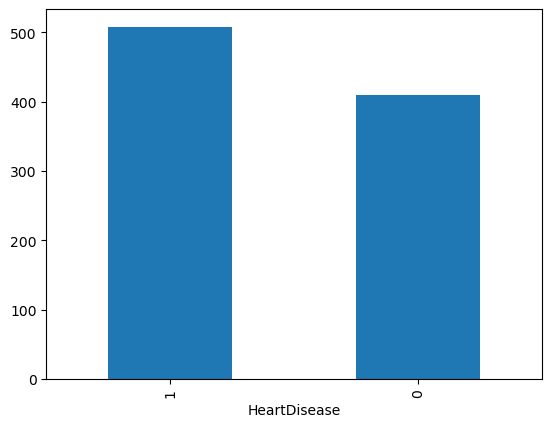

In [10]:
df["HeartDisease"].value_counts().plot(kind = "bar")

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

    In Python, a function is a block of code that performs a specific task and can be reused whenever needed. Instead of writing the same code again and again, you write it once inside a function and call it multiple times.
    syntax:
    def function_name(parameters):
        # code block
        return result
    
    Here, def is a keyword used to define a function.
    function_name is the name you give to the function.
    parameters are inputs (optional).
    return is used to send output back (optional).

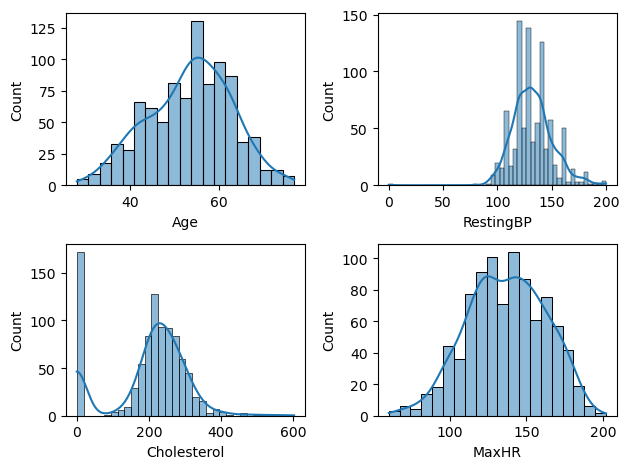

In [13]:
def plotting(var, num):
    plt.subplot(2,2,num)
    # This creates a grid of 2 rows and 2 columns (total 4 plots).
    # num tells where the current plot will appear.
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout() #It automatically adjusts spacing between plots

In [14]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [15]:
ch_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()

Step 1: df["Cholesterol"] != 0

This checks each row in the "Cholesterol" column.

If value is not 0 → True
If value is 0 → False

Example:

[200, 0, 180, 0, 220] → [True, False, True, False, True]

So basically, it is filtering out zero values.

Step 2: df.loc[...]

loc is used to select rows and columns.
loc in pandas is used to select data from a DataFrame using labels (names).

df.loc[condition, column_name]

In your case:

df.loc[df["Cholesterol"] != 0, "Cholesterol"]

Means:

Select only rows where Cholesterol ≠ 0
From those rows, take only the "Cholesterol" column

So you get something like:

[200, 180, 220]

This code means:
👉 “Find the average Cholesterol value, ignoring all rows where Cholesterol is 0.”

In [17]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)  #.round(2) → rounds each value to 2 digits after decimal

In [18]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
230.00      9
         ... 
392.00      1
316.00      1
153.00      1
466.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [19]:
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()
df['RestingBP'] = df['RestingBP'].replace(0,bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

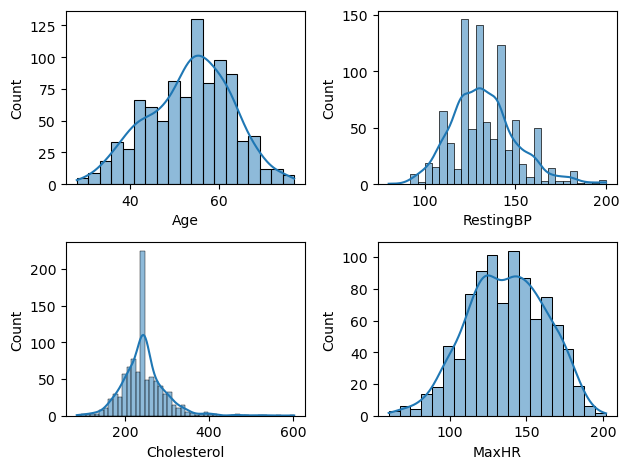

In [20]:
def plotting(var, num):
    plt.subplot(2,2,num)
  
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

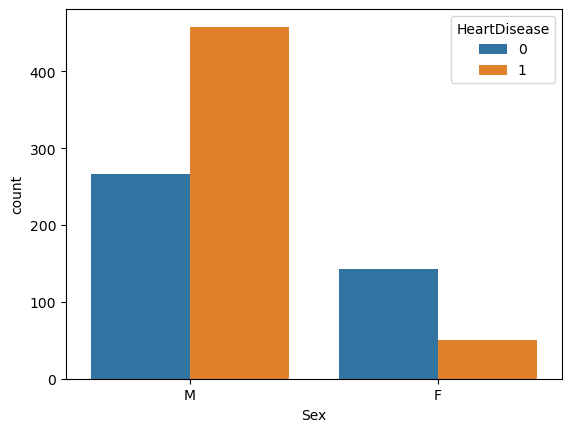

In [21]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])
# hue is used to separate data into subgroups and display them with different colors in the same plot.

<Axes: xlabel='ChestPainType', ylabel='count'>

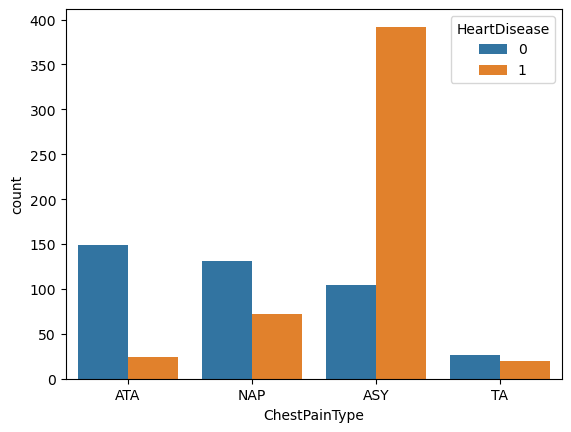

In [22]:
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

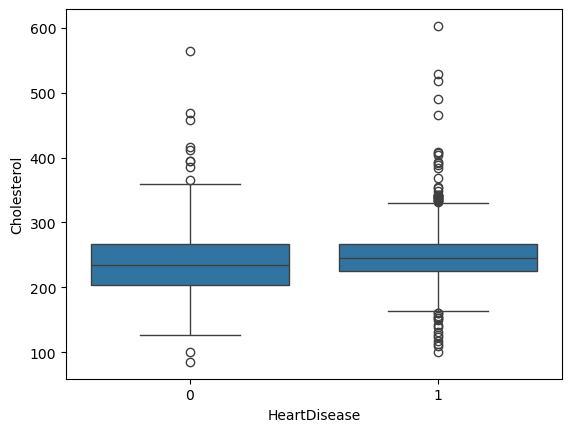

In [23]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

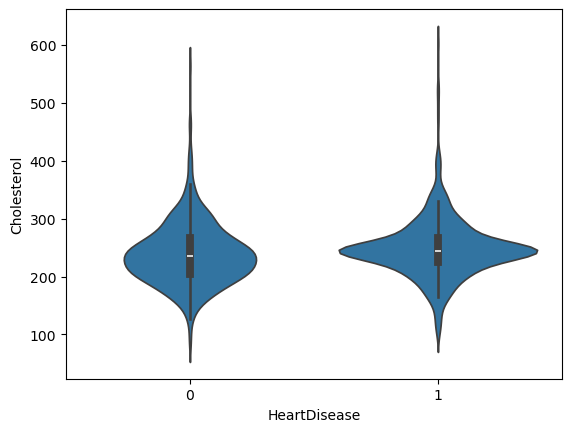

In [24]:
sns.violinplot(x='HeartDisease', y='Cholesterol', data=df)

<Axes: >

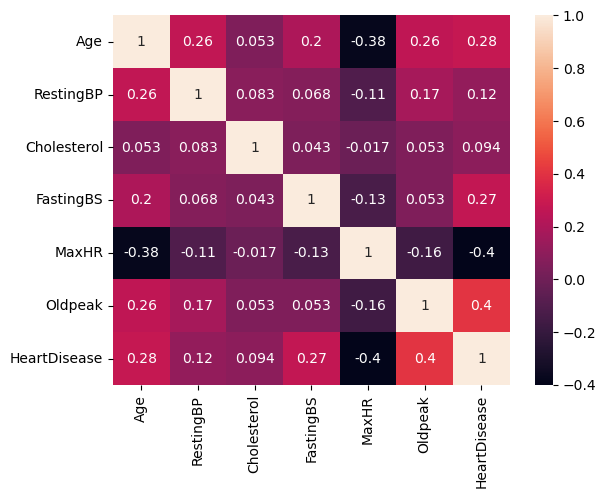

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [26]:
df_encode = pd.get_dummies(df, drop_first=True, dtype=int) # feature engineering

In [27]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [28]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak' ]
scaler = StandardScaler()
df_encode [numerical_cols] = scaler.fit_transform(df_encode [numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [30]:
x = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [33]:
models = {
    "logistic regression" : LogisticRegression(),
    "naive bayes" : GaussianNB(),
    "tree" : DecisionTreeClassifier(),
    "KNN" : KNeighborsClassifier(),
    "svm" : SVC()
}

In [34]:
result = []

In [35]:
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "model" : name,
        "accuracy" : round(acc,4),
        "f1 score" : round(f1,4)
    })
    

    append() is a method, it adds a new item to the end of a list.
    Example:
    numbers = [1, 2, 3]
    numbers.append(4)
    
    Now the list becomes:
    [1, 2, 3, 4]

In [37]:
result

[{'model': 'logistic regression', 'accuracy': 0.8641, 'f1 score': 0.8804},
 {'model': 'naive bayes', 'accuracy': 0.8533, 'f1 score': 0.8683},
 {'model': 'tree', 'accuracy': 0.788, 'f1 score': 0.8152},
 {'model': 'KNN', 'accuracy': 0.8533, 'f1 score': 0.8708},
 {'model': 'svm', 'accuracy': 0.8478, 'f1 score': 0.8679}]

In [38]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(x.columns.tolist(), 'column.pkl')

['column.pkl']